In [1]:
# ── Librerías estándar ───────────────────────────────────────────────────────
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# ── TensorFlow y Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as keras_image

# ── Versión instalada ─────────────────────────────────────────────────────────
print("TensorFlow versión:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))


TensorFlow versión: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ── Descargar el dataset ─────────────────────────────────────────────────────
import urllib.request
import tarfile

DATASET_URL  = "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar"
TAR_PATH     = "images.tar"
DATA_DIR     = "dataset/Images"

if not os.path.exists(DATA_DIR):
    print("[1/2] Descargando Stanford Dogs Dataset (~800 MB)...")
    urllib.request.urlretrieve(DATASET_URL, TAR_PATH)
    print("[2/2] Extrayendo archivos...")
    with tarfile.open(TAR_PATH, "r") as tar:
        tar.extractall("dataset/")
    print("✓ Dataset listo en:", DATA_DIR)
else:
    print("✓ Dataset ya existe en:", DATA_DIR)

# Verificar cuántas razas/carpetas hay
razas = sorted(os.listdir(DATA_DIR))
print(f"Número de razas detectadas: {len(razas)}")
print("Primeras 5 carpetas:", razas[:5])


[1/2] Descargando Stanford Dogs Dataset (~800 MB)...
[2/2] Extrayendo archivos...


/tmp/ipykernel_3116/2445513831.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("dataset/")


✓ Dataset listo en: dataset/Images
Número de razas detectadas: 120
Primeras 5 carpetas: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu']


Total de imágenes : 20580
Total de razas    : 120
Promedio por raza : 171
Mínimo por raza   : 148
Máximo por raza   : 252


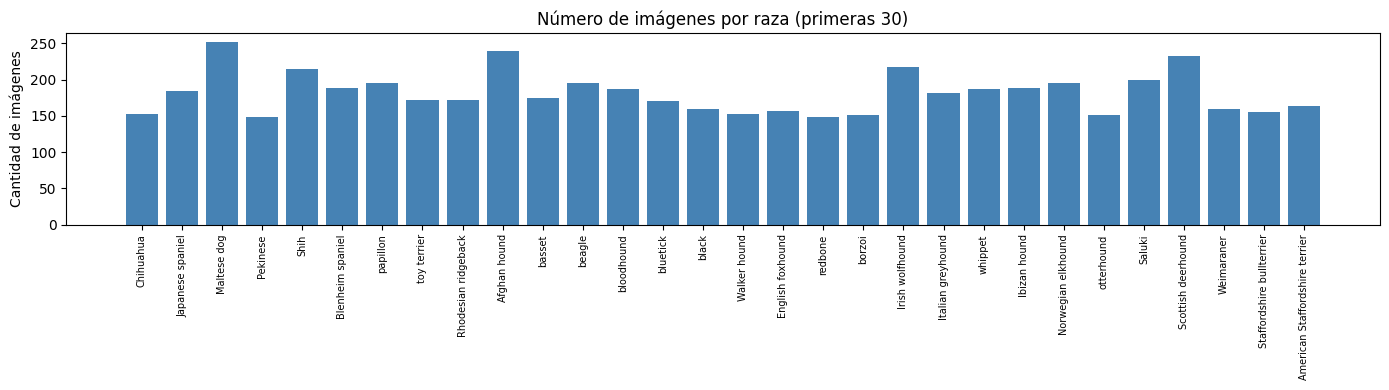

In [3]:
# ── Contar imágenes por raza ──────────────────────────────────────────────────
conteo = {}
total  = 0
for raza in sorted(os.listdir(DATA_DIR)):
    ruta  = os.path.join(DATA_DIR, raza)
    n     = len([f for f in os.listdir(ruta) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    conteo[raza] = n
    total += n

print(f"Total de imágenes : {total}")
print(f"Total de razas    : {len(conteo)}")
print(f"Promedio por raza : {total // len(conteo)}")
print(f"Mínimo por raza   : {min(conteo.values())}")
print(f"Máximo por raza   : {max(conteo.values())}")

# Visualizar distribución (primeras 30 razas)
nombres = [k.split('-')[1].replace('_',' ') for k in list(conteo.keys())[:30]]
valores = list(conteo.values())[:30]

plt.figure(figsize=(14, 4))
plt.bar(range(30), valores, color='steelblue')
plt.xticks(range(30), nombres, rotation=90, fontsize=7)
plt.title('Número de imágenes por raza (primeras 30)')
plt.ylabel('Cantidad de imágenes')
plt.tight_layout()
plt.show()


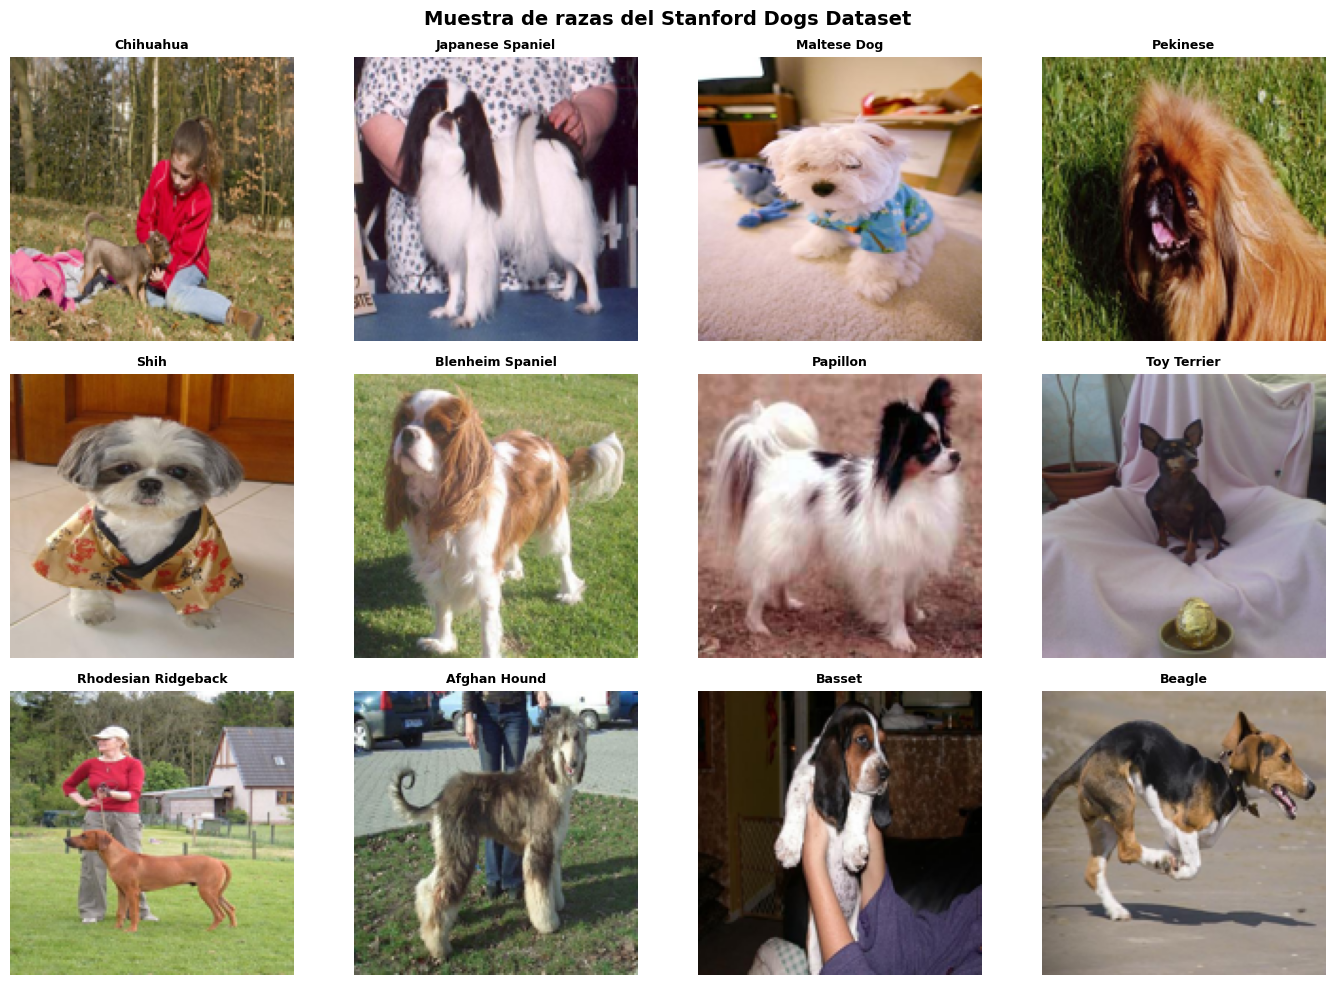

In [4]:
# ── Mostrar una muestra de imágenes por raza ─────────────────────────────────
from PIL import Image

muestra_razas = sorted(os.listdir(DATA_DIR))[:12]  # Primeras 12 razas
fig, axes     = plt.subplots(3, 4, figsize=(14, 10))
axes          = axes.flatten()

for i, raza in enumerate(muestra_razas):
    ruta_raza = os.path.join(DATA_DIR, raza)
    img_file  = os.listdir(ruta_raza)[0]
    img       = Image.open(os.path.join(ruta_raza, img_file)).resize((150, 150))
    axes[i].imshow(img)
    nombre_limpio = raza.split('-')[1].replace('_', ' ').title()
    axes[i].set_title(nombre_limpio, fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Muestra de razas del Stanford Dogs Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Raza de ejemplo  : n02085620-Chihuahua
Archivo          : n02085620_806.jpg
Tamaño original  : (800, 534)  (ancho × alto)
Modo de color    : RGB


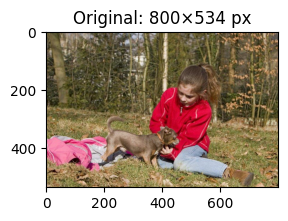

In [5]:
# ── Obtener tamaños originales de las imágenes ────────────────────────────────
from PIL import Image

raza_ejemplo   = sorted(os.listdir(DATA_DIR))[0]
ruta_raza_ej   = os.path.join(DATA_DIR, raza_ejemplo)
img_ejemplo    = os.listdir(ruta_raza_ej)[0]
img_pil        = Image.open(os.path.join(ruta_raza_ej, img_ejemplo))

print(f"Raza de ejemplo  : {raza_ejemplo}")
print(f"Archivo          : {img_ejemplo}")
print(f"Tamaño original  : {img_pil.size}  (ancho × alto)")
print(f"Modo de color    : {img_pil.mode}")

# Mostrar imagen original
plt.figure(figsize=(3, 3))
plt.imshow(img_pil)
plt.title(f"Original: {img_pil.size[0]}×{img_pil.size[1]} px")
plt.axis('on')
plt.show()


In [6]:
# ── Parámetros globales ───────────────────────────────────────────────────────
IMG_SIZE   = (224, 224)   # Tamaño requerido por MobileNetV2
BATCH_SIZE = 32           # Imágenes por batch
DATA_DIR   = "dataset/Images"

print(f"Tamaño de imagen  : {IMG_SIZE}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Normalización     : ÷ 255  →  rango [0, 1]")


Tamaño de imagen  : (224, 224)
Batch size        : 32
Normalización     : ÷ 255  →  rango [0, 1]


In [7]:
# ── Generadores de datos ──────────────────────────────────────────────────────

# Augmentación para entrenamiento
train_datagen = ImageDataGenerator(
    rescale           = 1.0 / 255,
    rotation_range    = 20,
    width_shift_range = 0.15,
    height_shift_range= 0.15,
    shear_range       = 0.1,
    zoom_range        = 0.2,
    horizontal_flip   = True,
    brightness_range  = [0.8, 1.2],
    fill_mode         = "nearest",
    validation_split  = 0.20,     # 20% para validación
)

# Solo normalización para validación
val_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = 0.20,
)

# Generador de entrenamiento
train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    subset      = "training",
    shuffle     = True,
    seed        = 42,
)

# Generador de validación
val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    subset      = "validation",
    shuffle     = False,
    seed        = 42,
)

NUM_CLASSES = len(train_gen.class_indices)
print(f"Clases detectadas     : {NUM_CLASSES}")
print(f"Imágenes entrenamiento: {train_gen.samples}")
print(f"Imágenes validación   : {val_gen.samples}")


Found 16508 images belonging to 120 classes.
Found 4072 images belonging to 120 classes.
Clases detectadas     : 120
Imágenes entrenamiento: 16508
Imágenes validación   : 4072


In [8]:
# ── Guardar etiquetas ─────────────────────────────────────────────────────────
os.makedirs("model", exist_ok=True)

labels_inv = {str(v): k for k, v in train_gen.class_indices.items()}

LABELS_SAVE = "model/class_labels.json"
with open(LABELS_SAVE, "w") as f:
    json.dump(labels_inv, f, indent=2)

print(f"✓ Etiquetas guardadas en: {LABELS_SAVE}")
print(f"Ejemplo: índice 0 → {labels_inv['0']}")


✓ Etiquetas guardadas en: model/class_labels.json
Ejemplo: índice 0 → n02085620-Chihuahua


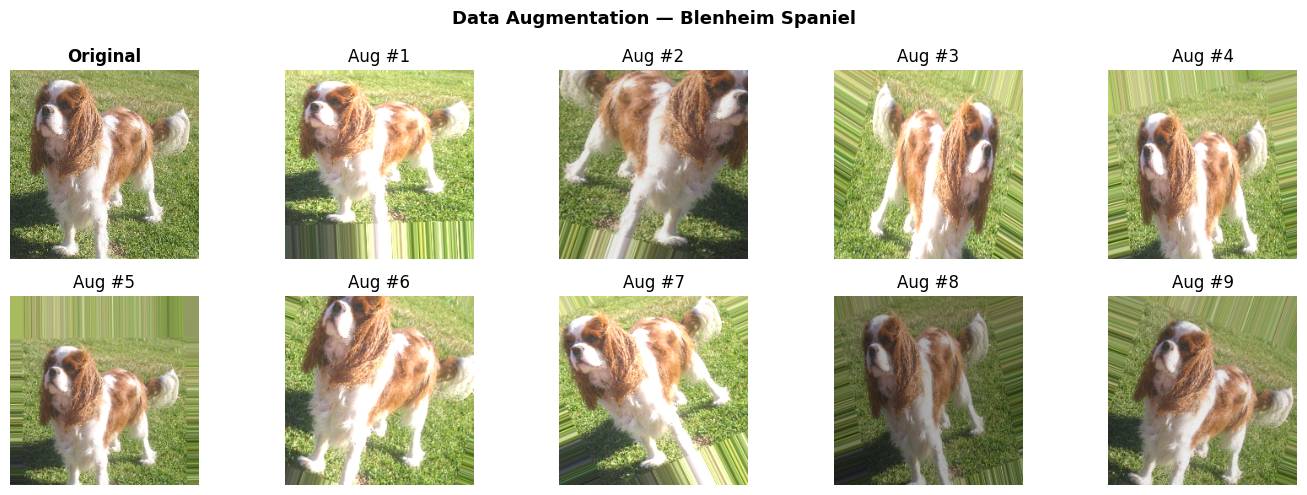

In [9]:
# ── Visualizar augmentación ───────────────────────────────────────────────────
from tensorflow.keras.preprocessing import image as keras_image

# Tomar una imagen de muestra
raza_ej  = sorted(os.listdir(DATA_DIR))[5]
img_file = os.listdir(os.path.join(DATA_DIR, raza_ej))[0]
img_path = os.path.join(DATA_DIR, raza_ej, img_file)

img = keras_image.load_img(img_path, target_size=IMG_SIZE)
x   = keras_image.img_to_array(img)
x   = x.reshape((1,) + x.shape)

aug_gen = ImageDataGenerator(
    rotation_range    = 25,
    width_shift_range = 0.2,
    zoom_range        = 0.25,
    horizontal_flip   = True,
    brightness_range  = [0.6, 1.4],
    fill_mode         = "nearest",
)

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
axes      = axes.flatten()

# Imagen original
axes[0].imshow(img)
axes[0].set_title("Original", fontweight='bold')
axes[0].axis('off')

# 9 versiones augmentadas
for i, batch in enumerate(aug_gen.flow(x, batch_size=1)):
    axes[i+1].imshow(batch[0].astype("uint8"))
    axes[i+1].set_title(f"Aug #{i+1}")
    axes[i+1].axis('off')
    if i == 8:
        break

nombre = raza_ej.split('-')[1].replace('_',' ').title()
plt.suptitle(f"Data Augmentation — {nombre}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [10]:
# ── Construcción del modelo ───────────────────────────────────────────────────

# Cargar MobileNetV2 sin la cabeza de clasificación original
backbone = MobileNetV2(
    input_shape = (*IMG_SIZE, 3),
    include_top = False,
    weights     = "imagenet",
)
backbone.trainable = False   # Fase 1: congelar todo el backbone

print(f"Capas en MobileNetV2 backbone: {len(backbone.layers)}")
print(f"Parámetros backbone (entrenables en fase 1): {backbone.count_params():,}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Capas en MobileNetV2 backbone: 154
Parámetros backbone (entrenables en fase 1): 2,257,984


In [11]:
# ── Cabeza de clasificación personalizada ─────────────────────────────────────
inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = backbone(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation="relu")(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs, name="DogBreed_MobileNetV2")
print("✓ Modelo construido correctamente")


✓ Modelo construido correctamente


In [ ]:
# ── Arquitectura del modelo ───────────────────────────────────────────────────
model.summary()


In [ ]:
# ── Compilar modelo ───────────────────────────────────────────────────────────
LEARNING_RATE = 1e-4

model.compile(
    optimizer = optimizers.Adam(learning_rate=LEARNING_RATE),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"],
)

print("✓ Modelo compilado")
print(f"  Optimizador  : Adam  |  LR = {LEARNING_RATE}")
print(f"  Loss         : Categorical Crossentropy")
print(f"  Métrica      : Accuracy")


In [ ]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
EPOCHS_HEAD = 10

cbs_head = [
    callbacks.ModelCheckpoint(
        "model/best_head.h5",
        monitor         = "val_accuracy",
        save_best_only  = True,
        verbose         = 1,
    ),
    callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1,
    ),
]

print(f"✓ Callbacks definidos para Fase 1 ({EPOCHS_HEAD} épocas máximo)")


In [ ]:
# ── Entrenamiento Fase 1 ──────────────────────────────────────────────────────
print("=" * 55)
print("  FASE 1: Entrenamiento de la cabeza densa")
print("  Backbone: CONGELADO")
print("=" * 55)

history_head = model.fit(
    train_gen,
    epochs          = EPOCHS_HEAD,
    validation_data = val_gen,
    callbacks       = cbs_head,
    verbose         = 1,
)


In [ ]:
# ── Graficar curvas de entrenamiento Fase 1 ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_head.history['accuracy'],     label='Train Accuracy',  color='royalblue',  linewidth=2)
axes[0].plot(history_head.history['val_accuracy'], label='Val Accuracy',    color='coral',      linewidth=2)
axes[0].set_title('Accuracy — Fase 1 (Cabeza)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_head.history['loss'],     label='Train Loss',  color='royalblue',  linewidth=2)
axes[1].plot(history_head.history['val_loss'], label='Val Loss',    color='coral',      linewidth=2)
axes[1].set_title('Loss — Fase 1 (Cabeza)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("model/history_fase1.png", dpi=150, bbox_inches='tight')
plt.show()

acc_final = history_head.history['val_accuracy'][-1]
print(f"Val Accuracy final Fase 1: {acc_final:.4f}  ({acc_final*100:.2f}%)")


In [ ]:
# ── Descongelar capas superiores del backbone ────────────────────────────────
FINE_TUNE_AT = 100   # Descongelar desde esta capa en adelante
FINE_TUNE_LR = 1e-5  # LR muy bajo para no destruir pesos preentrenados
EPOCHS_FINE  = 15

backbone.trainable = True
for layer in backbone.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompilar con LR más bajo
model.compile(
    optimizer = optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"],
)

# Contar parámetros entrenables ahora
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Capas descongeladas desde la capa {FINE_TUNE_AT}")
print(f"Parámetros entrenables ahora : {trainable:,}")
print(f"LR Fine-Tuning               : {FINE_TUNE_LR}")


In [ ]:
# ── Callbacks Fine-Tuning ─────────────────────────────────────────────────────
cbs_fine = [
    callbacks.ModelCheckpoint(
        "model/best_finetune.h5",
        monitor         = "val_accuracy",
        save_best_only  = True,
        verbose         = 1,
    ),
    callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-8,
        verbose  = 1,
    ),
]

print("=" * 55)
print("  FASE 2: Fine-Tuning del backbone")
print(f"  Backbone: PARCIALMENTE DESCONGELADO (capa {FINE_TUNE_AT}+)")
print("=" * 55)

history_fine = model.fit(
    train_gen,
    epochs          = EPOCHS_FINE,
    validation_data = val_gen,
    callbacks       = cbs_fine,
    verbose         = 1,
)


In [ ]:
# ── Curvas Fase 2 ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_fine.history['accuracy'],     label='Train Accuracy',  color='mediumseagreen', linewidth=2)
axes[0].plot(history_fine.history['val_accuracy'], label='Val Accuracy',    color='tomato',         linewidth=2)
axes[0].set_title('Accuracy — Fase 2 (Fine-Tuning)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_fine.history['loss'],     label='Train Loss',  color='mediumseagreen', linewidth=2)
axes[1].plot(history_fine.history['val_loss'], label='Val Loss',    color='tomato',         linewidth=2)
axes[1].set_title('Loss — Fase 2 (Fine-Tuning)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("model/history_fase2.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Historial combinado: Fase 1 + Fase 2 ─────────────────────────────────────
acc_h1  = history_head.history['accuracy']
acc_v1  = history_head.history['val_accuracy']
acc_h2  = history_fine.history['accuracy']
acc_v2  = history_fine.history['val_accuracy']

total_epochs = len(acc_h1) + len(acc_h2)
x1 = range(1, len(acc_h1)+1)
x2 = range(len(acc_h1)+1, total_epochs+1)

plt.figure(figsize=(12, 5))
plt.plot(x1, acc_h1, 'b--', label='Train Acc Fase 1', linewidth=1.5)
plt.plot(x1, acc_v1, 'r--', label='Val Acc Fase 1',   linewidth=1.5)
plt.plot(x2, acc_h2, 'b-',  label='Train Acc Fase 2', linewidth=2)
plt.plot(x2, acc_v2, 'r-',  label='Val Acc Fase 2',   linewidth=2)
plt.axvline(x=len(acc_h1)+0.5, color='gray', linestyle=':', label='Inicio Fine-Tuning')
plt.title('Accuracy — Entrenamiento Completo (Fase 1 + Fine-Tuning)', fontsize=13, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Val Accuracy final: {acc_v2[-1]*100:.2f}%")


In [ ]:
# ── Evaluación en validación ──────────────────────────────────────────────────
print("Evaluando modelo en conjunto de validación...")
val_loss, val_acc = model.evaluate(val_gen, verbose=1)

print()
print("=" * 40)
print(f"  Val Loss     : {val_loss:.4f}")
print(f"  Val Accuracy : {val_acc:.4f}  ({val_acc*100:.2f}%)")
print("=" * 40)


In [ ]:
# ── Visualizar predicciones ───────────────────────────────────────────────────
import numpy as np

# Cargar etiquetas
with open("model/class_labels.json") as f:
    labels = json.load(f)

# Tomar un batch de validación
val_gen.reset()
batch_imgs, batch_labels = next(val_gen)
preds = model.predict(batch_imgs, verbose=0)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i in range(12):
    img        = batch_imgs[i]
    pred_idx   = np.argmax(preds[i])
    real_idx   = np.argmax(batch_labels[i])
    pred_name  = labels[str(pred_idx)].split('-')[-1].replace('_',' ').title()
    real_name  = labels[str(real_idx)].split('-')[-1].replace('_',' ').title()
    confianza  = preds[i][pred_idx] * 100
    correcto   = pred_idx == real_idx

    axes[i].imshow(img)
    color = 'green' if correcto else 'red'
    symbol = '✓' if correcto else '✗'
    axes[i].set_title(
        f"{symbol} Pred: {pred_name}
({confianza:.1f}%)",
        fontsize=8, color=color, fontweight='bold'
    )
    axes[i].set_xlabel(f"Real: {real_name}", fontsize=7, color='gray')
    axes[i].axis('off')

plt.suptitle('Predicciones sobre validación  (Verde=Correcto, Rojo=Incorrecto)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Extraer Feature Maps de la primera capa conv del backbone ────────────────
from tensorflow.keras import Input

# Tomar una imagen de muestra del dataset
raza_fm   = sorted(os.listdir(DATA_DIR))[10]
img_file  = os.listdir(os.path.join(DATA_DIR, raza_fm))[2]
img_path  = os.path.join(DATA_DIR, raza_fm, img_file)

img_fm    = keras_image.load_img(img_path, target_size=IMG_SIZE)
x_fm      = keras_image.img_to_array(img_fm) / 255.0
x_fm      = np.expand_dims(x_fm, axis=0)

# Mostrar imagen original
plt.figure(figsize=(3, 3))
plt.imshow(img_fm)
raza_nombre = raza_fm.split('-')[1].replace('_',' ').title()
plt.title(f'Imagen: {raza_nombre}')
plt.axis('on')
plt.show()
print(f"Shape de entrada al modelo: {x_fm.shape}")


In [ ]:
# ── Modelo para extraer activaciones de capas convolucionales ────────────────
# Construir sub-modelo: Input → primera capa Conv del backbone
backbone_layers = [l for l in backbone.layers if 'conv' in l.name.lower()]
print(f"Número de capas convolucionales en el backbone: {len(backbone_layers)}")
print("Primeras 5 capas conv:", [l.name for l in backbone_layers[:5]])

# Modelo hasta la primera capa conv (32 filtros)
feature_model_1 = models.Model(
    inputs  = backbone.input,
    outputs = backbone_layers[0].output
)

feature_maps_1 = feature_model_1.predict(x_fm, verbose=0)
print(f"Shape Feature Maps (1ª conv): {feature_maps_1.shape}")
# Ejemplo: (1, 112, 112, 32)


In [ ]:
# ── Visualizar los primeros 32 mapas de activación (1ª conv) ─────────────────
num_maps = min(32, feature_maps_1.shape[-1])
cols     = 8
rows     = num_maps // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 2))
axes      = axes.flatten()

for i in range(num_maps):
    axes[i].imshow(feature_maps_1[0, :, :, i], cmap='Greys')
    axes[i].axis('off')
    axes[i].set_title(f'F{i+1}', fontsize=7)

plt.suptitle(f'Feature Maps — 1ª Capa Convolucional (32 filtros) | {raza_nombre}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Feature Maps de una capa más profunda ─────────────────────────────────────
# Usar una capa conv más avanzada para ver características de mayor nivel
capa_profunda = backbone_layers[15]   # Capa más avanzada
print(f"Capa seleccionada: {capa_profunda.name} | Output shape: {capa_profunda.output.shape}")

feature_model_deep = models.Model(
    inputs  = backbone.input,
    outputs = capa_profunda.output
)
feature_maps_deep = feature_model_deep.predict(x_fm, verbose=0)
print(f"Shape Feature Maps profundos: {feature_maps_deep.shape}")

# Mostrar primeros 32 mapas
n_show   = min(32, feature_maps_deep.shape[-1])
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes      = axes.flatten()

for i in range(n_show):
    axes[i].imshow(feature_maps_deep[0, :, :, i], cmap='viridis')
    axes[i].axis('off')

plt.suptitle(f'Feature Maps — Capa Profunda ({capa_profunda.name}) | {raza_nombre}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Cargar imagen desde URL para predicción ──────────────────────────────────
import requests
from io import BytesIO
from PIL import Image

# URL de ejemplo: un Golden Retriever (puedes cambiarla por cualquier imagen de perro)
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b3/Golden_retriever_eating_pigs_foot.jpg/640px-Golden_retriever_eating_pigs_foot.jpg"

response = requests.get(url)
img_pred = Image.open(BytesIO(response.content))

print(f"Imagen cargada desde URL")
print(f"Tamaño original: {img_pred.size}")

plt.figure(figsize=(4, 4))
plt.imshow(img_pred)
plt.title("Imagen original (antes de preprocesar)")
plt.axis('on')
plt.show()


In [ ]:
# ── Preprocesar imagen ────────────────────────────────────────────────────────
img_resized = img_pred.resize(IMG_SIZE)

plt.figure(figsize=(3, 3))
plt.imshow(img_resized)
plt.title(f"Redimensionada: {IMG_SIZE[0]}×{IMG_SIZE[1]} px")
plt.axis('on')
plt.show()

# Convertir a array, normalizar y añadir dimensión de batch
img_array = keras_image.img_to_array(img_resized)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

print(f"Shape del tensor de entrada: {img_array.shape}")
print(f"Rango de valores: [{img_array.min():.3f}, {img_array.max():.3f}]")


In [ ]:
# ── Realizar predicción ───────────────────────────────────────────────────────
predicciones = model.predict(img_array, verbose=0)[0]

# Cargar etiquetas
with open("model/class_labels.json") as f:
    labels_dict = json.load(f)

# Limpiar nombres de razas
def limpiar_nombre(nombre_raw):
    return nombre_raw.split('-')[-1].replace('_', ' ').title()

# Top 5 predicciones
top5_idx    = np.argsort(predicciones)[::-1][:5]
top5_razas  = [limpiar_nombre(labels_dict[str(i)]) for i in top5_idx]
top5_probs  = [predicciones[i] * 100 for i in top5_idx]

print("Predicciones:")
print(class_names := [limpiar_nombre(labels_dict[str(i)]) for i in range(len(labels_dict))])
print()
print("Top 5 razas predichas:")
for i, (raza, prob) in enumerate(zip(top5_razas, top5_probs)):
    emoji = "🏆" if i == 0 else f"  {i+1}."
    print(f"  {emoji}  {raza:<35}  {prob:.2f}%")


In [ ]:
# ── Mostrar resultado final ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Imagen con predicción
axes[0].imshow(img_resized)
axes[0].set_title(
    f"🏆 {top5_razas[0]}\n{top5_probs[0]:.1f}% de confianza",
    fontsize=13, fontweight='bold', color='darkgreen'
)
axes[0].axis('off')

# Gráfica de barras Top 5
colors = ['gold'] + ['steelblue'] * 4
axes[1].barh(top5_razas[::-1], top5_probs[::-1], color=colors[::-1])
axes[1].set_xlabel('Probabilidad (%)')
axes[1].set_title('Top 5 Predicciones del Modelo', fontweight='bold')
for i, (v, r) in enumerate(zip(top5_probs[::-1], top5_razas[::-1])):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# ── Guardar modelo en formato nativo Keras (.keras) ──────────────────────────
model.save('model/dog_breed_mobilenetv2.keras')
print("✓ Modelo guardado: model/dog_breed_mobilenetv2.keras")


In [ ]:
# ── Guardar en formato HDF5 (.h5) ─────────────────────────────────────────────
model.save('model/dog_breed_mobilenetv2.h5')
print("✓ Modelo guardado: model/dog_breed_mobilenetv2.h5")


In [ ]:
# ── Guardar arquitectura JSON + pesos H5 ──────────────────────────────────────
model_json = model.to_json()

with open('model/dog_breed_arquitectura.json', 'w') as f:
    f.write(model_json)
print("✓ Arquitectura guardada: model/dog_breed_arquitectura.json")

model.save_weights('model/dog_breed_pesos.weights.h5')
print("✓ Pesos guardados     : model/dog_breed_pesos.weights.h5")


In [ ]:
# ── Cargar modelo guardado ────────────────────────────────────────────────────
from tensorflow.keras.models import load_model

# Cargar desde .keras
modelo_cargado = load_model('model/dog_breed_mobilenetv2.keras')
print("✓ Modelo cargado desde .keras")
print(f"  Input  shape: {modelo_cargado.input_shape}")
print(f"  Output shape: {modelo_cargado.output_shape}")


In [ ]:
# ── Convertir a TFLite ────────────────────────────────────────────────────────
converter   = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('model/dog_breed_mobilenetv2.tflite', 'wb') as f:
    f.write(tflite_model)

print("✓ Modelo TFLite guardado: model/dog_breed_mobilenetv2.tflite")
print(f"  Tamaño: {len(tflite_model) / 1e6:.2f} MB")


In [ ]:
# ── Descargar archivos desde Google Colab ─────────────────────────────────────
from google.colab import files
import zipfile

# Comprimir carpeta model/
with zipfile.ZipFile('modelo_razas_perros.zip', 'w') as zipf:
    for root, dirs, fs in os.walk('model/'):
        for file in fs:
            zipf.write(os.path.join(root, file))

print("✓ Archivos comprimidos en: modelo_razas_perros.zip")
files.download('modelo_razas_perros.zip')


In [ ]:
# ── Instalar Streamlit en Colab (para visualizar el código) ──────────────────
# Nota: Streamlit no corre directamente en Colab, se ejecuta localmente con:
#   streamlit run app.py
# O se despliega en Streamlit Cloud (https://streamlit.io/cloud)

# Mostrar el contenido del archivo app.py
app_code = '''
import os, json
import numpy as np
from PIL import Image
import streamlit as st
import tensorflow as tf
import plotly.graph_objects as go

st.set_page_config(page_title="DogBreed AI", page_icon="🐾", layout="wide")

IMG_SIZE   = (224, 224)
MODEL_PATH = "model/dog_breed_mobilenetv2.h5"
LABELS_PATH= "model/class_labels.json"
TOP_K      = 5

@st.cache_resource
def load_model_and_labels():
    model  = tf.keras.models.load_model(MODEL_PATH)
    with open(LABELS_PATH) as f:
        raw = json.load(f)
    labels = {int(k): v.split("-")[-1].replace("_"," ").title() for k,v in raw.items()}
    return model, labels

def preprocess(img):
    img = img.convert("RGB").resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32) / 255.0
    return np.expand_dims(arr, axis=0)

model, labels = load_model_and_labels()

st.title("🐾 DogBreed AI — Clasificador de Razas")
col1, col2 = st.columns(2)

with col1:
    uploaded = st.file_uploader("Sube una foto de perro", type=["jpg","jpeg","png","webp"])
    if uploaded:
        img = Image.open(uploaded)
        st.image(img, use_container_width=True)
        if st.button("🔍 Clasificar"):
            preds    = model.predict(preprocess(img), verbose=0)[0]
            top5_idx = np.argsort(preds)[::-1][:TOP_K]
            breeds   = [labels[i] for i in top5_idx]
            probs    = [preds[i]*100 for i in top5_idx]
            with col2:
                st.markdown(f"### 🏆 {breeds[0]}")
                st.metric("Confianza", f"{probs[0]:.1f}%")
                fig = go.Figure(go.Bar(x=probs, y=breeds, orientation="h"))
                st.plotly_chart(fig, use_container_width=True)
'''

print(app_code)
